In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy
import os

## Helper Functions

In [41]:
def clean_cols(df):
    #concat all columns that start with "AA03" into one column, and all columns that start with "Uncoated" into another column, then return the dataframe with only these 2 columns
    aa03_cols = df.filter(regex=r'^AA03',axis=1)
    uncoated_cols = df.filter(regex=r'^uncoated',axis=1)
    se02_cols = df.filter(regex=r'^SE02',axis=1)
    uncoated_cols_2 = df.filter(regex=r'^uncoated_2',axis=1)

    return pd.DataFrame({
        #"Time": df["Time"],
        "AA03": aa03_cols.mean(axis=1), #take the mean of all columns that start with AA03
        "Uncoated": uncoated_cols.mean(axis=1), #take the mean of all columns that start with Uncoated
        "Uncoated_2": uncoated_cols_2.mean(axis=1), #take the mean of all columns that start with Uncoated_2
        "SE02": se02_cols.mean(axis=1) #take the mean of all columns that start with SE02
    })

def remove_outliers_rolling(df, col, window, threshold):
    #2 step process, 1st is applying rolling median to remove outliers, then SMA for smoothing
    rolling_median = df[col].rolling(window, center=True, min_periods=1).median()
    diff = (df[col] - rolling_median).abs()

    removed = (diff>=threshold).sum()
    print(f"Removed {removed} outliers from column {col} using rolling median with window {window} and threshold {threshold}.")

    df[col] = df[col].where(diff < threshold, np.nan)
    return df

def smoothen(df, window_size):
    return df.rolling(window=window_size, min_periods=1).mean()

def detect_stable_segments(
        df, col, 
        smooth_window=30, #smmoth over 30s
        gradient_window=30, #gradient avergaed over 30s
        stable_threshold=0.03, #less than 0.02 deg is considered stable
        min_stable_length=120, #shoudl be stable for at least 2 minutes
        rise_threshold=0.07, #above 0.06 deg is considered rising
        lookback_window=600): #look back after 10 min for a rise
    df = df.copy()

    signal = df[col].rolling(window=smooth_window, min_periods=1).mean()
    gradient = signal.diff().fillna(0)
    gradient_smooth = gradient.rolling(window=gradient_window, min_periods=1).mean()

    stable = gradient_smooth.abs() < stable_threshold
    rising = gradient_smooth > rise_threshold

    start_marker_col = f"{col}_stable_start_marker"
    end_marker_col = f"{col}_stable_end_marker"
    segment_col = f"{col}_stable_segment"
    segment_id_col = f"{col}_segment_id"

    df[start_marker_col] = np.nan
    df[end_marker_col] = np.nan
    df[segment_col] = False
    df[segment_id_col] = np.nan

    #non stable runs
    stable_group_id = (stable != stable.shift()).cumsum()

    stable_segments = []
    segment_number = 0

    for _, segment in df[stable].groupby(stable_group_id[stable]):
        if len(segment) < min_stable_length:
            continue

        start_idx = segment.index[0]
        end_idx = segment.index[-1]

        #check whetehr there is a rise before the stable segment
        lookback_start = max(0, start_idx - lookback_window)

        had_recent_rise = rising.loc[lookback_start:start_idx].any()

        if not had_recent_rise:
            continue

        segment_number += 1

        stable_segments.append((start_idx, end_idx))

        #start marker
        df.loc[start_idx, start_marker_col] = df[col].max()
        #end marker
        df.loc[end_idx, end_marker_col] = df[col].max()
        #segment marker
        df.loc[start_idx:end_idx, segment_col] = True
        #segment ID
        df.loc[start_idx:end_idx, segment_id_col] = segment_number
    print(f"Detected {len(stable_segments)} stable segments in column {col}")

    return df

In [52]:
folders = 'g:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/'
directory = 'test_2005'
file = os.path.join(folders, directory, 'master_logs.csv')

print(file)
df = pd.read_csv(file)
print(df.head())
print(df.columns)

g:/Shared drives/Sharing - General/Technical/Data Analysis/Current Cycling/Logs/test_2005\master_logs.csv
   AA03_temp  SE02_temp  uncoated_temp  uncoated_2_temp  \
0  20.111705  20.244048      20.215958        20.216584   
1  20.114855  20.244232      20.214911        20.216264   
2  20.112873  20.243188      20.214302        20.218791   
3  20.111977  20.244011      20.213053        20.218426   
4  20.111474  20.244324      20.212831        20.218177   

                       source_file  index      time  stable_marker  \
0  LogFile_2026-05-20-12-15-41.csv      0  00:00:00            NaN   
1  LogFile_2026-05-20-12-15-41.csv      1  00:00:01            NaN   
2  LogFile_2026-05-20-12-15-41.csv      2  00:00:02            NaN   
3  LogFile_2026-05-20-12-15-41.csv      3  00:00:03            NaN   
4  LogFile_2026-05-20-12-15-41.csv      4  00:00:04            NaN   

   stable_segment  
0           False  
1           False  
2           False  
3           False  
4           False 

In [53]:
df = clean_cols(df)
print(df)


            AA03    Uncoated  Uncoated_2        SE02
0      20.111705   20.216271   20.216584   20.244048
1      20.114855   20.215587   20.216264   20.244232
2      20.112873   20.216547   20.218791   20.243188
3      20.111977   20.215739   20.218426   20.244011
4      20.111474   20.215504   20.218177   20.244324
...          ...         ...         ...         ...
1964  123.367431  119.862886  119.942189  133.215403
1965  123.367407  119.857888  119.943728  133.195957
1966  123.368220  119.853213  119.945407  133.175508
1967  123.369340  119.848900  119.946249  133.154627
1968  123.370923  119.845769  119.946799  133.134561

[1969 rows x 4 columns]


In [54]:
df = detect_stable_segments(df, 'AA03', smooth_window=30, gradient_window=30, stable_threshold=0.02, min_stable_length=120, rise_threshold=0.07, lookback_window=600)
df
#print index of aa03_stable_segment that are True
print(df[df['AA03_stable_start_marker'].notnull()].index)
print(df[df['AA03_stable_end_marker'].notnull()].index)

Detected 1 stable segments in column AA03
Index([1622], dtype='int64')
Index([1968], dtype='int64')


Removed 0 outliers from column AA03 using rolling median with window 30 and threshold 1.
Removed 0 outliers from column Uncoated using rolling median with window 30 and threshold 1.
Removed 0 outliers from column Uncoated_2 using rolling median with window 30 and threshold 1.
Removed 0 outliers from column SE02 using rolling median with window 30 and threshold 1.


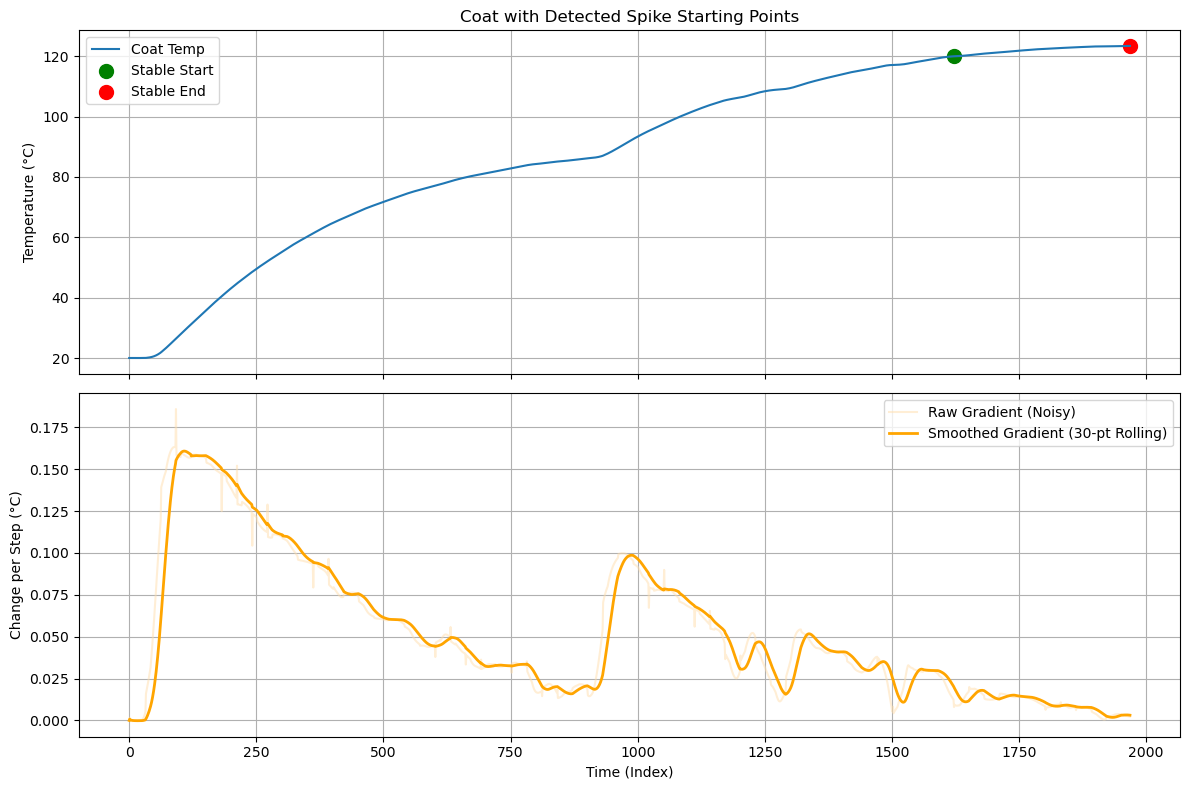

In [55]:
start_col = 'AA03_stable_start_marker'
end_col = 'AA03_stable_end_marker'

cols = ["AA03", "Uncoated", "Uncoated_2", "SE02"]
for col in cols:    
    df = remove_outliers_rolling(df, col, window=30, threshold=1)
df[cols] = smoothen(df[cols], window_size=30)

index = df.index
coat_aa03 = df['AA03']
coat_se02 = df['SE02']
coat_uncoated = df['Uncoated']
raw_gradient = coat_aa03.diff().fillna(0)  # Calculate the gradient and fill NaN values with 0
coat_gradient_smooth = raw_gradient.rolling(window=30, min_periods=1).mean()



fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: Raw Temperature with detected start times
ax1.plot(index, coat_aa03, label='Coat Temp', color='#1f77b4')
# ax1.plot(index, coat_se02, label='SE02 Temp', color='#ff7f0e')
# ax1.plot(index, coat_uncoated, label='Uncoated Temp', color='#9d9d9c')
ax1.scatter(df[df[start_col].notnull()].index,
            df.loc[df[start_col].notnull(), 'AA03'],
            color='green', marker='o', s=100, label='Stable Start')

ax1.scatter(df[df[end_col].notnull()].index,
            df.loc[df[end_col].notnull(), 'AA03'],
            color='red', marker='o', s=100, label='Stable End')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Coat with Detected Spike Starting Points')
ax1.legend()
ax1.grid(True)

# Bottom Plot: The Gradient (Rate of Change) showing the actual peaks
ax2.plot(index, raw_gradient, label='Raw Gradient (Noisy)', color='navajowhite', alpha=0.5)
ax2.plot(index, coat_gradient_smooth, label='Smoothed Gradient (30-pt Rolling)', color='orange', lw=2)
#ax2.scatter(index[peaks], coat_gradient_smooth[peaks], color='red', marker='x', s=120, lw=2.5)
ax2.set_xlabel('Time (Index)')
ax2.set_ylabel('Change per Step (°C)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Removed 0 outliers from column AA03 using rolling median with window 30 and threshold 1.
Removed 0 outliers from column Uncoated using rolling median with window 30 and threshold 1.
Removed 0 outliers from column Uncoated_2 using rolling median with window 30 and threshold 1.
Removed 0 outliers from column SE02 using rolling median with window 30 and threshold 1.


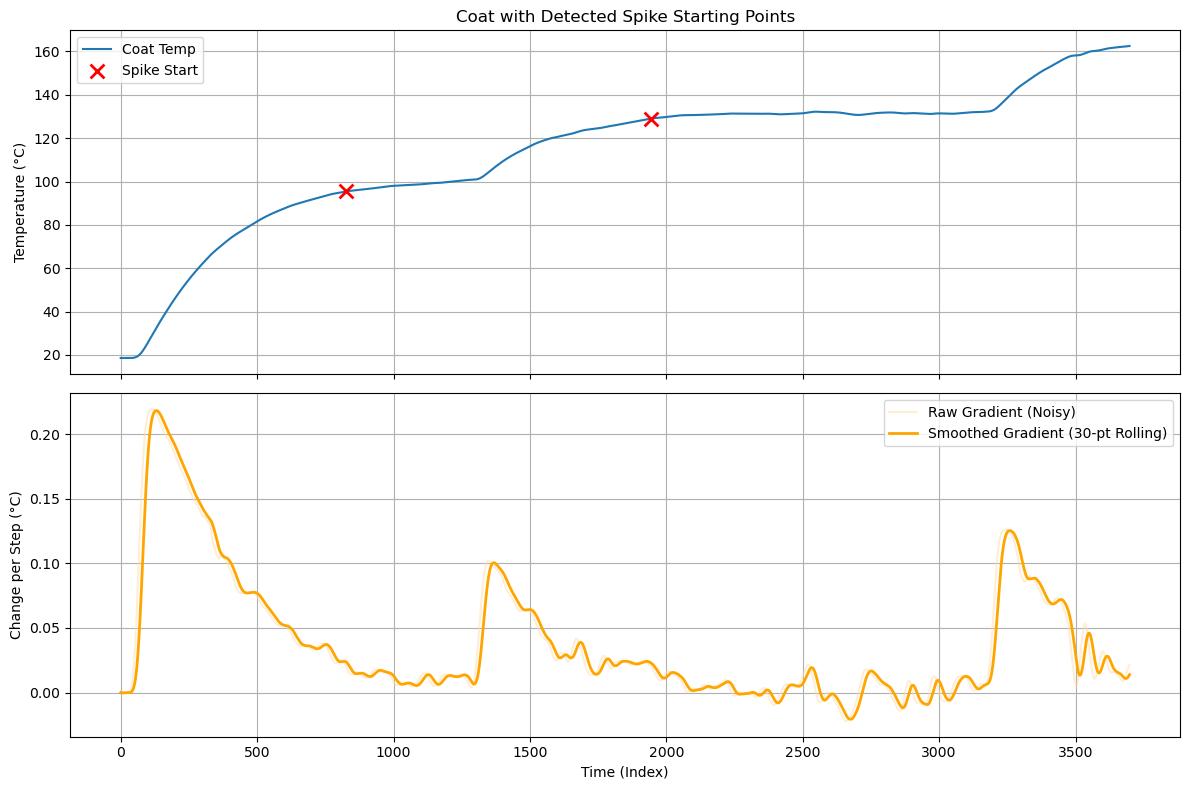

In [28]:
from scipy.signal import find_peaks

#coat = df['AA03_temp']

cols = ["AA03", "Uncoated", "Uncoated_2", "SE02"]
for col in cols:    
    df = remove_outliers_rolling(df, col, window=30, threshold=1)
df[cols] = smoothen(df[cols], window_size=30)

index = df.index
coat_aa03 = df['AA03']
coat_se02 = df['SE02']
coat_uncoated = df['Uncoated']
raw_gradient = coat_aa03.diff().fillna(0)  # Calculate the gradient and fill NaN values with 0
coat_gradient_smooth = raw_gradient.rolling(window=30, min_periods=1).mean()  # Smooth the gradient with a rolling mean

#now detect spikes in coat using scipy.signal.find_peaks
# peaks, _ = find_peaks(
#     coat_gradient_smooth, 
#     height=0.08, #y-value (temp) threshold
#     distance=300, #big distance to avoid multiple peaks
#     prominence=0.05)  # How much peak stands out from the baseline

# window_offset = 50
# adjusted_peaks = [max(0, p-window_offset) for p in peaks]
#minus 15 to get the start of the spike, but ensure we don't go below index 0


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top Plot: Raw Temperature with detected start times
ax1.plot(index, coat_aa03, label='Coat Temp', color='#1f77b4')
# ax1.plot(index, coat_se02, label='SE02 Temp', color='#ff7f0e')
# ax1.plot(index, coat_uncoated, label='Uncoated Temp', color='#9d9d9c')
ax1.scatter(df[df['AA03_stable_marker'].notnull()].index, coat_aa03[df['AA03_stable_marker'].notnull()], color='red', marker='x', s=100, lw=2, label='Spike Start', zorder=5)
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Coat with Detected Spike Starting Points')
ax1.legend()
ax1.grid(True)

# Bottom Plot: The Gradient (Rate of Change) showing the actual peaks
ax2.plot(index, raw_gradient, label='Raw Gradient (Noisy)', color='navajowhite', alpha=0.5)
ax2.plot(index, coat_gradient_smooth, label='Smoothed Gradient (30-pt Rolling)', color='orange', lw=2)
#ax2.scatter(index[peaks], coat_gradient_smooth[peaks], color='red', marker='x', s=120, lw=2.5)
ax2.set_xlabel('Time (Index)')
ax2.set_ylabel('Change per Step (°C)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [1]:
print(5//2)
print(5%2)

2
1
